In [1]:
%pip install -e "/home/jupyter/mlops-meta-learning/fsl-projekt[dev]"

Obtaining file:///home/jupyter/mlops-meta-learning/fsl-projekt
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fsl-projekt (pyproject.toml) ... done
  Created wheel for fsl-projekt: filename=fsl_projekt-0.1.0-0.editable-py3-none-any.whl size=1396 sha256=ae80f093a98e5ee623e872b2a50aa1039ddaa2c3f4464367f6f6dcbe0faa9a20
  Stored in directory: /var/tmp/pip-ephem-wheel-cache-rnjl8rta/wheels/a5/8d/db/09c9babf91f973f877caf4fc7085772ab8b63bd65a8f087244
Successfully built fsl-projekt
  Attempting uninstall: fsl-projekt
    Found existing installation: fsl-projekt 0.1.0
    Uninstalling fsl-projekt-0.1.0:
      Successfully uninstalled fsl-projekt-0.1.0
Note: you may need to restart the kernel to use updated packages.


# Rung 2 — First learning loop: ProtoNet on Omniglot

The first rung where **something learns**. This notebook:

1. Loads the **frozen, verified** Omniglot from GCS (not the internet).
2. Builds N-way K-shot **episodes** (the core few-shot construct).
3. Trains a **Prototypical Network** (the simplest meta-learner).
4. Logs **parameters + summary metrics** to Vertex AI Experiments.

**Rung-2 gate (before moving up):** you can (a) reproduce the same result from
the same seed, and (b) explain how an *episode* differs from an ordinary batch.

The goal here is *correct, reproducible mechanics you understand* — not a high
accuracy number.

## 1. Configuration

Everything tunable lives here — config is a *parameter*, logged once per run.

In [2]:
# --- EDIT THESE ---
PROJECT  = "dark-data-discovery"      # same project as the data
REGION   = "us-central1"          # same region as the bucket
BUCKET   = f"{PROJECT}-fsl-data"  # where the frozen data lives
EXPERIMENT_NAME = "fsl-omniglot-protonet"

# --- episode config (few-shot is defined by these two numbers) ---
N_WAY   = 5        # classes per episode
K_SHOT  = 5        # labeled support examples per class
QUERY   = 15       # query examples per class (standard)

# --- training config ---
SEED            = 0
TRAIN_ITERS     = 2000     # training episodes (iterations)
EVAL_EVERY      = 250      # validate every N iterations
VAL_EPISODES    = 200      # episodes per validation
TEST_EPISODES   = 1000     # episodes for the final reported number (mean +/- CI)
LR              = 1e-3
EMBEDDING_HID   = 64       # conv4 channel width

# local cache for the extracted dataset (persistent home disk)
import os
CACHE_DIR = os.path.expanduser("~/data_cache/omniglot")

## 2. Imports and reproducibility

Seed every RNG up front — reproducibility is the point of rung 2.

In [3]:
import random, time, json, gzip, tarfile
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import learn2learn as l2l
from torchvision import transforms

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)   # CPU is fine for Omniglot at this scale

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device: cpu


/home/jupyter/envs/fsl/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 3. Load the frozen dataset from GCS

We download the **frozen archive** from GCS and extract it locally — we do *not*
re-download from the internet. This is the link from rung 1 (frozen data) to
rung 2 (training): the loop reads exactly the bytes we froze and verified.

We also read the manifest to capture `archive_sha256` — logged later as a
parameter, so each run is tied to the exact data version it trained on.

In [4]:
from google.cloud import storage

cache = Path(CACHE_DIR)
archive_blob = "raw/omniglot/omniglot.tar.gz"
manifest_blob = "raw/omniglot/MANIFEST.json"

client = storage.Client(project=PROJECT)
bucket = client.bucket(BUCKET)

# read manifest (provenance: which exact data version)
manifest = json.loads(bucket.blob(manifest_blob).download_as_bytes().decode("utf-8"))
DATASET_SHA = manifest["archive_sha256"]
print("Frozen archive SHA256:", DATASET_SHA[:16], "...")

# download + extract once (skip if already extracted)
if not (cache / "omniglot-py").exists():
    cache.mkdir(parents=True, exist_ok=True)
    archive = cache / "omniglot.tar.gz"
    print("Downloading frozen archive from GCS ...")
    bucket.blob(archive_blob).download_to_filename(str(archive))
    print("Extracting ...")
    with open(archive, "rb") as raw, gzip.GzipFile(fileobj=raw) as gz, tarfile.open(fileobj=gz) as tar:
        tar.extractall(cache)   # our own trusted archive
    print("Done.")
else:
    print("Already extracted at", cache)

Frozen archive SHA256: d3259526f8f84cab ...
Already extracted at /home/jupyter/data_cache/omniglot


**Verify the extracted layout** before handing it to learn2learn. FullOmniglot
expects an `omniglot-py/` folder under its `root`. If the path differs from what
the cell below prints, adjust `root=` in the next cell accordingly.

In [5]:
# show what was extracted, so we can confirm FullOmniglot will find it
for p in sorted(cache.rglob("*"))[:8]:
    print(p.relative_to(cache))
print("...")
assert (cache / "omniglot-py").exists(), \
    "Expected 'omniglot-py/' under the cache dir; inspect the listing above and set root accordingly."
print("\nLayout OK: omniglot-py/ present.")

omniglot-bookkeeping.pkl
omniglot-py
omniglot-py/images_background
omniglot-py/images_background/Alphabet_of_the_Magi
omniglot-py/images_background/Alphabet_of_the_Magi/character01
omniglot-py/images_background/Alphabet_of_the_Magi/character01/0709_01.png
omniglot-py/images_background/Alphabet_of_the_Magi/character01/0709_02.png
omniglot-py/images_background/Alphabet_of_the_Magi/character01/0709_03.png
...

Layout OK: omniglot-py/ present.


## 4. Build episodic task samplers

We point `FullOmniglot` at the **already-extracted** data with `download=False`.
Omniglot's standard meta-split is **1100 / 100 / 423** classes (train/val/test) —
the test classes are *never seen in training*, which is the whole point of
few-shot: learn to learn *new* classes, not memorize fixed ones.

The transform pipeline per task: pick `N_WAY` classes, sample `K_SHOT+QUERY`
examples each, load, remap labels to `0..N-1`, sort consecutively. Training tasks
also get `RandomClassRotation` (the standard Omniglot augmentation: a rotated
character is treated as a new class).

In [6]:
try:
    from torchvision.transforms import InterpolationMode
    _resize = transforms.Resize(28, interpolation=InterpolationMode.LANCZOS)
except Exception:
    _resize = transforms.Resize(28)

omniglot = l2l.vision.datasets.FullOmniglot(
    root=str(cache),
    download=False,                      # use the frozen, extracted data
    transform=transforms.Compose([
        _resize,
        transforms.ToTensor(),
        lambda x: 1.0 - x,               # invert: white character on black
    ]),
)
dataset = l2l.data.MetaDataset(omniglot)

# standard 1100/100/423 split over the 1623 classes (seeded shuffle)
classes = list(range(1623))
random.Random(SEED).shuffle(classes)
split = {
    "train": classes[:1100],
    "val":   classes[1100:1200],
    "test":  classes[1200:],
}

def make_tasks(label_subset, num_tasks, augment=False):
    T = l2l.data.transforms
    tfs = [
        T.FilterLabels(dataset, label_subset),
        T.NWays(dataset, N_WAY),
        T.KShots(dataset, K_SHOT + QUERY),   # support + query per class
        T.LoadData(dataset),
        T.RemapLabels(dataset),
        T.ConsecutiveLabels(dataset),        # group samples by class (needed for the split)
    ]
    if augment:
        tfs.append(l2l.vision.transforms.RandomClassRotation(dataset, [0.0, 90.0, 180.0, 270.0]))
    return l2l.data.TaskDataset(dataset, task_transforms=tfs, num_tasks=num_tasks)

train_tasks = make_tasks(split["train"], num_tasks=20000, augment=True)
val_tasks   = make_tasks(split["val"],   num_tasks=VAL_EPISODES)
test_tasks  = make_tasks(split["test"],  num_tasks=TEST_EPISODES)
print("Task samplers ready (train/val/test).")

Task samplers ready (train/val/test).


## 5. Inspect one episode

**This cell is the rung-2 gate made visible.** An episode is *not* a batch: it is
a self-contained mini learning problem — a small labeled *support set* and an
unlabeled *query set* over `N_WAY` freshly-sampled classes. Run it and read the
shapes.

Episode tensor X: (100, 1, 28, 28)   labels y: (100,)
Unique labels (remapped to 0..N-1): [0, 1, 2, 3, 4]
Total samples = N_WAY*(K_SHOT+QUERY) = 5*20 = 100


/var/tmp/ipykernel_47099/3815404234.py:1: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  X, y = train_tasks.sample()


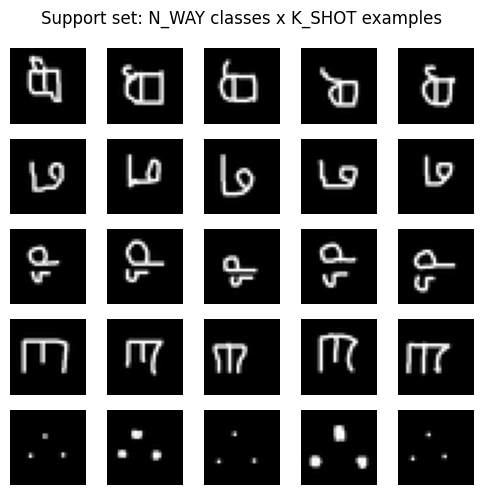

In [7]:
X, y = train_tasks.sample()
print("Episode tensor X:", tuple(X.shape), "  labels y:", tuple(y.shape))
print("Unique labels (remapped to 0..N-1):", sorted(set(y.tolist())))
print(f"Total samples = N_WAY*(K_SHOT+QUERY) = {N_WAY}*{K_SHOT+QUERY} = {N_WAY*(K_SHOT+QUERY)}")

# visualize the support set (first K_SHOT of each class after sorting)
import matplotlib.pyplot as plt
sort = torch.sort(y)
Xs, ys = X[sort.indices], y[sort.indices]
fig, axes = plt.subplots(N_WAY, K_SHOT, figsize=(K_SHOT, N_WAY))
for c in range(N_WAY):
    for k in range(K_SHOT):
        idx = c * (K_SHOT + QUERY) + k
        ax = axes[c, k]
        ax.imshow(Xs[idx, 0], cmap="gray"); ax.axis("off")
        if k == 0: ax.set_ylabel(f"cls {c}", rotation=0, labelpad=15)
fig.suptitle("Support set: N_WAY classes x K_SHOT examples")
plt.tight_layout(); plt.show()

## 6. Prototypical Network

Conv4 encoder; prototype = mean support embedding per class; classify query by nearest prototype. The `fast_adapt` split logic below was verified against the canonical learn2learn pattern.

In [8]:
def conv_block(in_c, out_c):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c),
        nn.ReLU(), nn.MaxPool2d(2),
    )

class Conv4(nn.Module):
    # Standard 4-block few-shot encoder -> flat embedding.
    def __init__(self, in_c=1, hid=64):
        super().__init__()
        self.net = nn.Sequential(
            conv_block(in_c, hid), conv_block(hid, hid),
            conv_block(hid, hid), conv_block(hid, hid),
        )
    def forward(self, x):
        return self.net(x).flatten(1)

def fast_adapt(model, batch, ways, shot, query, device):
    data, labels = batch
    data, labels = data.to(device), labels.to(device)
    # sort by label so samples of each class are contiguous
    sort = torch.sort(labels)
    data = data[sort.indices]
    labels = labels[sort.indices]
    emb = model(data)
    # split: first `shot` of each class block -> support, rest -> query
    support_mask = np.zeros(data.size(0), dtype=bool)
    selection = np.arange(ways) * (shot + query)
    for offset in range(shot):
        support_mask[selection + offset] = True
    support_mask_t = torch.from_numpy(support_mask).to(device)
    query_mask_t = torch.from_numpy(~support_mask).to(device)

    prototypes = emb[support_mask_t].reshape(ways, shot, -1).mean(dim=1)  # (ways, dim)
    q = emb[query_mask_t]
    q_labels = labels[query_mask_t].long()
    logits = -torch.cdist(q, prototypes)          # nearest prototype
    loss = F.cross_entropy(logits, q_labels)
    acc = (logits.argmax(1) == q_labels).float().mean()
    return loss, acc

model = Conv4(in_c=1, hid=EMBEDDING_HID).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
print(model)

Conv4(
  (net): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv2d(64, 

## 7. Start the Vertex AI Experiments run + log parameters

Parameters (config + **data provenance**) are logged once. `dataset_archive_sha256` ties this run to the exact data version.

In [9]:
from google.cloud import aiplatform

aiplatform.init(project=PROJECT, location=REGION, experiment=EXPERIMENT_NAME)
run_name = f"protonet-{N_WAY}w{K_SHOT}s-seed{SEED}-{int(time.time())}"
aiplatform.start_run(run_name)

aiplatform.log_params({
    "model": "protonet",
    "encoder": "conv4",
    "embedding_hid": EMBEDDING_HID,
    "distance": "euclidean",
    "n_way": N_WAY,
    "k_shot": K_SHOT,
    "query": QUERY,
    "seed": SEED,
    "train_iters": TRAIN_ITERS,
    "lr": LR,
    "optimizer": "adam",
    "eval_episodes": TEST_EPISODES,
    "dataset": "omniglot",
    "dataset_archive_sha256": DATASET_SHA,   # provenance: exact data version
})
print("Run started:", run_name)

/home/jupyter/envs/fsl/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
/home/jupyter/envs/fsl/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
/home/jupyter/envs/fsl/lib/python3.10/site-packages/

Associating projects/815755318672/locations/us-central1/metadataStores/default/contexts/fsl-omniglot-protonet-protonet-5w5s-seed0-1782861676 to Experiment: fsl-omniglot-protonet


Run started: protonet-5w5s-seed0-1782861676


## 8. Training loop

Each iteration = one training episode. We validate periodically and print the curve (time-series metrics -> TensorBoard is the next small step; here we keep params + summary).

In [10]:
def evaluate(tasks, n_episodes):
    model.eval()
    accs = []
    with torch.no_grad():
        for _ in range(n_episodes):
            _, acc = fast_adapt(model, tasks.sample(), N_WAY, K_SHOT, QUERY, device)
            accs.append(acc.item())
    model.train()
    return np.array(accs)

set_seed(SEED)   # re-seed right before the loop for reproducibility
t0 = time.time()
for it in range(1, TRAIN_ITERS + 1):
    opt.zero_grad()
    loss, acc = fast_adapt(model, train_tasks.sample(), N_WAY, K_SHOT, QUERY, device)
    loss.backward()
    opt.step()

    if it % EVAL_EVERY == 0 or it == 1:
        val = evaluate(val_tasks, VAL_EPISODES)
        print(f"iter {it:5d} | train loss {loss.item():.3f} acc {acc.item():.3f} "
              f"| val acc {val.mean():.3f} +/- {1.96*val.std()/np.sqrt(len(val)):.3f}")

train_time = time.time() - t0
print(f"\nTraining done in {train_time:.1f}s")

/var/tmp/ipykernel_47099/2228913928.py:6: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  _, acc = fast_adapt(model, tasks.sample(), N_WAY, K_SHOT, QUERY, device)


iter     1 | train loss 1.030 acc 0.733 | val acc 0.798 +/- 0.011


/var/tmp/ipykernel_47099/2228913928.py:15: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  loss, acc = fast_adapt(model, train_tasks.sample(), N_WAY, K_SHOT, QUERY, device)


iter   250 | train loss 0.021 acc 1.000 | val acc 0.982 +/- 0.003
iter   500 | train loss 0.006 acc 1.000 | val acc 0.984 +/- 0.002
iter   750 | train loss 0.246 acc 0.907 | val acc 0.985 +/- 0.003
iter  1000 | train loss 0.078 acc 0.973 | val acc 0.990 +/- 0.002
iter  1250 | train loss 0.013 acc 1.000 | val acc 0.989 +/- 0.002
iter  1500 | train loss 0.061 acc 0.973 | val acc 0.990 +/- 0.002
iter  1750 | train loss 0.004 acc 1.000 | val acc 0.993 +/- 0.001
iter  2000 | train loss 0.009 acc 1.000 | val acc 0.991 +/- 0.002

Training done in 873.2s


## 9. Final evaluation + log summary metrics

Few-shot accuracy is reported as **mean +/- 95% CI** over many test episodes — a single episode is noise. This is the falsifiable number.

In [11]:
test_accs = evaluate(test_tasks, TEST_EPISODES)
mean = float(test_accs.mean())
ci95 = float(1.96 * test_accs.std() / np.sqrt(len(test_accs)))
print(f"TEST {N_WAY}-way {K_SHOT}-shot: {mean*100:.2f}% +/- {ci95*100:.2f}%  "
      f"(over {TEST_EPISODES} episodes)")

aiplatform.log_metrics({
    "test_accuracy_mean": mean,
    "test_accuracy_ci95": ci95,
    "test_accuracy_std": float(test_accs.std()),
    "train_time_seconds": float(train_time),
})
aiplatform.end_run()
print("Logged to Vertex AI Experiments and ended run.")

/var/tmp/ipykernel_47099/2228913928.py:6: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  _, acc = fast_adapt(model, tasks.sample(), N_WAY, K_SHOT, QUERY, device)


TEST 5-way 5-shot: 99.22% +/- 0.08%  (over 1000 episodes)
Logged to Vertex AI Experiments and ended run.


## Rung-2 gate

Before moving to rung 3, confirm both:

1. **Reproducibility** — re-run the whole notebook with the same `SEED`; the final
   `test_accuracy_mean` should match (within tiny numerical noise).
2. **Understanding** — you can explain, in your own words, how an *episode*
   (support + query over freshly sampled classes, test classes unseen in training)
   differs from an ordinary supervised *batch* (fixed classes, i.i.d. samples).

In the Vertex console (Experiments -> `fsl-omniglot-protonet`) you should now see
this run with its parameters (including `dataset_archive_sha256`) and summary
metrics — the experiment is tied to the exact frozen data version it used.

**Next (rung 2.5 / 3):** attach Vertex TensorBoard to log the *time-series*
metrics (train/val curves per step), then refactor this notebook into the
`src/fsl/` modules (`data/`, `models/`, `training/`).